In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_matches = pd.read_csv('matches.csv')
print('Columns of matches.csv: ',df_matches.columns.tolist())
df_deliveries = pd.read_csv('deliveries.csv')
print('Columns of deliveries.csv: ',df_deliveries.columns.tolist())

Columns of matches.csv:  ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
Columns of deliveries.csv:  ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [3]:
df_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

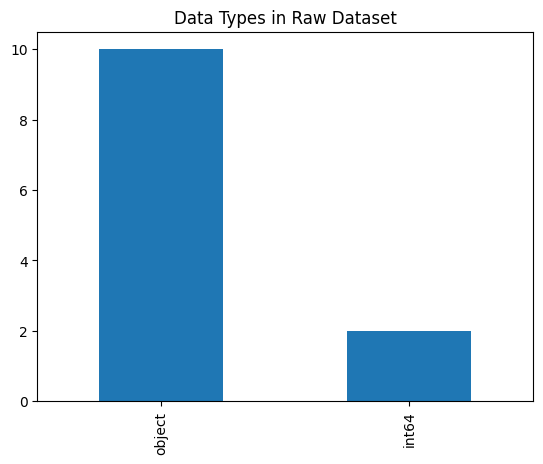

In [42]:
import matplotlib.pyplot as plt

df_matches.dtypes.value_counts().plot(kind='bar')
plt.title("Data Types in Raw Dataset")
plt.show()


In [4]:
df_matches.describe()


,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [5]:
df_matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

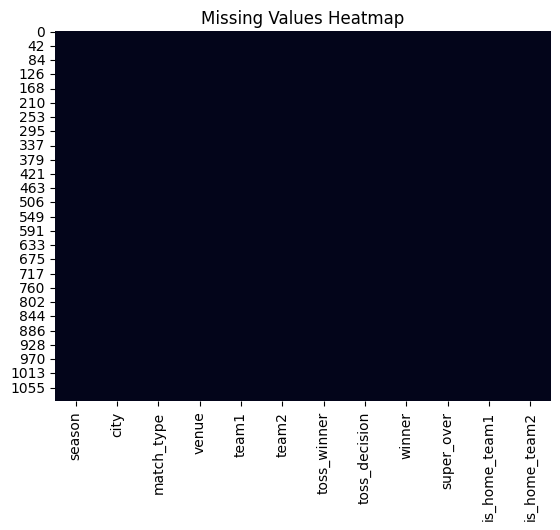

In [43]:
import seaborn as sns

sns.heatmap(df_matches.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [6]:
df_matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


Drop irrelavant columns

In [7]:
df_matches= df_matches.drop(columns=['id','date','player_of_match','result','result_margin','method','umpire1','umpire2','target_runs','target_overs'])
df_matches.head()

,season,city,match_type,venue,team1,team2,toss_winner,toss_decision,winner,super_over
0,2007/08,Bangalore,League,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,N
1,2007/08,Chandigarh,League,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,N
2,2007/08,Delhi,League,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,N
3,2007/08,Mumbai,League,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,N
4,2007/08,Kolkata,League,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,N


In [8]:
df_matches.columns

Index(['season', 'city', 'match_type', 'venue', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner', 'super_over'],
      dtype='object')

In [9]:
df_matches.isnull().sum()

season            0
city             51
match_type        0
venue             0
team1             0
team2             0
toss_winner       0
toss_decision     0
winner            5
super_over        0
dtype: int64

In [10]:
df_matches = df_matches[df_matches['winner'].notna()]

In [11]:
df_matches['city'] = df_matches['city'].fillna('Unknown')


In [12]:
df_matches.isnull().sum()

season           0
city             0
match_type       0
venue            0
team1            0
team2            0
toss_winner      0
toss_decision    0
winner           0
super_over       0
dtype: int64

In [13]:
df_matches['team1'].unique()
df_matches['team2'].unique()
df_matches['winner'].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Daredevils',
       'Royal Challengers Bangalore', 'Rajasthan Royals',
       'Kings XI Punjab', 'Deccan Chargers', 'Mumbai Indians',
       'Pune Warriors', 'Kochi Tuskers Kerala', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

Mapping same team different names, for eg. Delhi Daredevils and Delhi Capitals -> same franchise

In [14]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}


In [15]:
cols = ['team1', 'team2', 'winner', 'toss_winner']

for col in cols:
    df_matches.loc[:, col] = df_matches[col].replace(team_mapping)


In [16]:
print(df_matches['team1'].unique())
print(df_matches['team2'].unique())
print(df_matches['winner'].unique())


['Royal Challengers Bengaluru' 'Punjab Kings' 'Delhi Capitals'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Lucknow Super Giants' 'Gujarat Titans']
['Kolkata Knight Riders' 'Chennai Super Kings' 'Rajasthan Royals'
 'Royal Challengers Bengaluru' 'Deccan Chargers' 'Punjab Kings'
 'Delhi Capitals' 'Mumbai Indians' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Rising Pune Supergiant' 'Gujarat Lions'
 'Gujarat Titans' 'Lucknow Super Giants']
['Kolkata Knight Riders' 'Chennai Super Kings' 'Delhi Capitals'
 'Royal Challengers Bengaluru' 'Rajasthan Royals' 'Punjab Kings'
 'Deccan Chargers' 'Mumbai Indians' 'Pune Warriors' 'Kochi Tuskers Kerala'
 'Sunrisers Hyderabad' 'Rising Pune Supergiant' 'Gujarat Lions'
 'Gujarat Titans' 'Lucknow Super Giants']


Team playing at home ground winning %

In [17]:
team_home_city = {
    'Mumbai Indians': 'Mumbai',
    'Chennai Super Kings': 'Chennai',
    'Kolkata Knight Riders': 'Kolkata',
    'Royal Challengers Bengaluru': 'Bangalore',
    'Delhi Capitals': 'Delhi',
    'Punjab Kings': 'Mohali',
    'Rajasthan Royals': 'Jaipur',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Lucknow Super Giants': 'Lucknow',
    'Gujarat Titans': 'Ahmedabad'
}


In [18]:
# map home cities
df_matches['team1_home_city'] = df_matches['team1'].map(team_home_city)
df_matches['team2_home_city'] = df_matches['team2'].map(team_home_city)

#create home advantage feature
df_matches['is_home_team1'] = (df_matches['team1_home_city'] == df_matches['city']).astype(int)
df_matches['is_home_team2'] = (df_matches['team2_home_city'] == df_matches['city']).astype(int)

In [19]:
df_matches = df_matches.drop(columns=['team1_home_city','team2_home_city'])

Convert team1, team2, toss_winner, venue, city  into numbers

In [20]:
df_matches_encoded = pd.get_dummies(
    df_matches,
    columns=['team1', 'team2', 'toss_winner', 'venue', 'city'],
    drop_first=True
)

In [21]:
df_matches_encoded.head()

,season,match_type,toss_decision,winner,super_over,is_home_team1,is_home_team2,team1_Deccan Chargers,team1_Delhi Capitals,team1_Gujarat Lions,...,city_Nagpur,city_Navi Mumbai,city_Port Elizabeth,city_Pune,city_Raipur,city_Rajkot,city_Ranchi,city_Sharjah,city_Unknown,city_Visakhapatnam
0,2007/08,League,field,Kolkata Knight Riders,N,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2007/08,League,bat,Chennai Super Kings,N,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2007/08,League,bat,Delhi Capitals,N,1,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2007/08,League,bat,Royal Challengers Bengaluru,N,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2007/08,League,bat,Kolkata Knight Riders,N,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


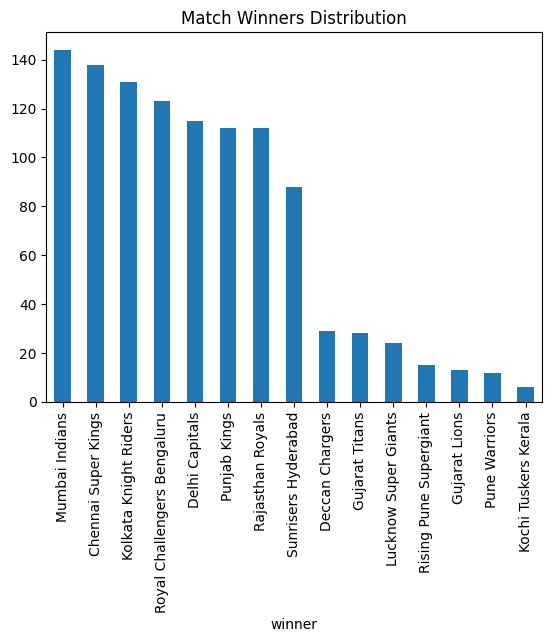

In [44]:
df_matches['winner'].value_counts().plot(kind='bar')
plt.title("Match Winners Distribution")
plt.show()


In [24]:
bool_cols = df_matches_encoded.select_dtypes(include='bool').columns
df_matches_encoded[bool_cols] = df_matches_encoded[bool_cols].astype(int)
df_matches_encoded.head()


,season,match_type,toss_decision,winner,super_over,is_home_team1,is_home_team2,team1_Deccan Chargers,team1_Delhi Capitals,team1_Gujarat Lions,...,city_Nagpur,city_Navi Mumbai,city_Port Elizabeth,city_Pune,city_Raipur,city_Rajkot,city_Ranchi,city_Sharjah,city_Unknown,city_Visakhapatnam
0,2007/08,League,field,Kolkata Knight Riders,N,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007/08,League,bat,Chennai Super Kings,N,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2007/08,League,bat,Delhi Capitals,N,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2007/08,League,bat,Royal Challengers Bengaluru,N,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2007/08,League,bat,Kolkata Knight Riders,N,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
df_matches_encoded.info()
df_matches_encoded.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Columns: 142 entries, season to city_Visakhapatnam
dtypes: int64(137), object(5)
memory usage: 1.2+ MB


season                0
match_type            0
toss_decision         0
winner                0
super_over            0
                     ..
city_Rajkot           0
city_Ranchi           0
city_Sharjah          0
city_Unknown          0
city_Visakhapatnam    0
Length: 142, dtype: int64

Machine learning and Building the pipeline

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_matches_encoded = pd.get_dummies(
    df_matches,
    columns=['team1', 'team2', 'toss_winner', 'venue', 'city'],
    drop_first=True
)

df_matches_encoded['winner_encoded'] = le.fit_transform(df_matches_encoded['winner'])

df_matches_encoded = df_matches_encoded.copy()


In [29]:
X = df_matches_encoded.drop(['winner', 'winner_encoded'], axis = 1)
y = df_matches_encoded['winner_encoded']

In [30]:
X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Columns: 141 entries, season to city_Visakhapatnam
dtypes: bool(135), int64(2), object(4)
memory usage: 203.3+ KB


In [33]:
X.select_dtypes(include='object').columns

Index(['season', 'match_type', 'toss_decision', 'super_over'], dtype='object')

In [34]:
X = pd.get_dummies(X, columns=['season', 'match_type', 'toss_decision', 'super_over'], drop_first=True)

In [35]:
print(X.dtypes.value_counts())


bool     160
int64      2
Name: count, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42)

Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [38]:
y_pred = model.predict(X_test)

Evaluate performance

In [40]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.48623853211009177
              precision    recall  f1-score   support

           0       0.61      0.38      0.47        37
           1       0.33      0.50      0.40         2
           2       0.44      0.55      0.49        20
           3       1.00      0.40      0.57         5
           4       0.75      0.33      0.46         9
           5       0.00      0.00      0.00         2
           6       0.50      0.48      0.49        23
           7       0.50      0.67      0.57         3
           8       0.48      0.54      0.51        26
           9       0.00      0.00      0.00         3
          10       0.35      0.45      0.39        20
          11       0.64      0.64      0.64        25
          12       1.00      0.50      0.67         4
          13       0.48      0.57      0.52        28
          14       0.28      0.45      0.34        11

    accuracy                           0.49       218
   macro avg       0.49      0.43      0.44      

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Random forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.518348623853211
